## Code Implementation

In [1]:
from PIL import Image

In [2]:
def message_to_binary(message):
    """Converts a text string into a binary string."""
    binary_message = ""
    for char in message:
        # Here ord() returns the ASCII code of a character. For character 'H', ord(H)=72. Then format() is used to format the output in desired 
        # manner, it can be binary, hexa-decimal or octa-decimal. '08b' represents the condition of fomatting 'b' means binary, '8' means no. of bits,
        #'0' means addition of leading zeros on left if a character does not have 8 binary bits.
        binary_message += format(ord(char), '08b')
    # Add a delimiter (null character) so the decoder knows when to stop. format(0, '08b') gives '00000000'.
    binary_message += format(0, '08b')
    return binary_message

def binary_to_message(binary_data):
    """Converts a string of binary digits back into text."""
    message = ""
    # Process 8 bits at a time (1 byte per character). Loop uses step size of 8 and counts the binary string in '0,8,16,...' order. 
    # On the first loop (i=0), it takes index 0 to 8. If binary data starts with "0100100001101001", byte becomes just "01001000".
    # The int() function converts a string into a regular number, Example:The binary string "01001000" gets converted into the integer 72.
    # The chr() takes the ASCII value from char_code and converts it into character. Opposite of ord()
    for i in range(0, len(binary_data), 8):
        byte = binary_data[i:i+8]
        char_code = int(byte, 2)
        if char_code == 0:  # Stop if we hit the delimiter
            break
        message += chr(char_code)
    return message

def encode_image(image_path, secret_message, output_path):
    """Embeds a secret message into a RGB image using LSB."""
    # open and convert the image in RGB format. load the image in the temporary storage,RAM as a 2D grid.Take height and width of the image to
    # traverse rows and columns. msg_index exactly tracks the bit being hidden, starts with 0 and it is incremented by 1.
    img = Image.open(image_path).convert('RGB')
    pixels = img.load()
    width, height = img.size
    
    binary_msg = message_to_binary(secret_message)
    msg_index = 0
    msg_len = len(binary_msg)
    
    # Loop through every pixel in the image.Top-left pixel first.
    for y in range(height):
        for x in range(width):
            if msg_index >= msg_len:
                break  # whole message is embedded
                
            # Get the current RGB values
            r, g, b = pixels[x, y]
            
            # Modify Red channel LSB
            if msg_index < msg_len:
                r = (r & ~1) | int(binary_msg[msg_index])
                msg_index += 1
                
            # Modify Green channel LSB
            if msg_index < msg_len:
                g = (g & ~1) | int(binary_msg[msg_index])
                msg_index += 1
                
            # Modify Blue channel LSB
            if msg_index < msg_len:
                b = (b & ~1) | int(binary_msg[msg_index])
                msg_index += 1
                
            # Save the modified pixels back into the image
            pixels[x, y] = (r, g, b)
            
        if msg_index >= msg_len:
            break
            
    # Save as PNG to avoid compressing away the hidden data
    img.save(output_path, "PNG")
    print(f"Message hidden successfully in {output_path}!")

def decode_image(image_path):
    """Extracts the hidden message from the RGB image."""
    img = Image.open(image_path).convert('RGB')
    pixels = img.load()
    width, height = img.size
    
    binary_data = ""
    
    # Loop through pixels to collect the LSBs
    for y in range(height):
        for x in range(width):
            r, g, b = pixels[x, y]
            
            # Pull the last bit from each color channel (& 1)
            binary_data += str(r & 1)
            binary_data += str(g & 1)
            binary_data += str(b & 1)
            
            # Check periodically if we hit our 8-bit null delimiter
            if len(binary_data) % 8 == 0:
                # Look at the last 8 bits extracted
                last_byte = binary_data[-8:]
                if int(last_byte, 2) == 0:
                    return binary_to_message(binary_data)
                    
    return binary_to_message(binary_data)

# --- Example ---
if __name__ == "__main__":
    # 1. Hide the message
    # input_image.jpg must exist in the directory
    encode_image("input_image.jpg", "Hello, this is a secret!", "encoded_image.png")
    
    # 2. Extract the message
    decoded_text = decode_image("encoded_image.png")
    print(f"Decoded Message: {decoded_text}")

Message hidden successfully in encoded_image.png!
Decoded Message: Hello, this is a secret!


## Image Plotting

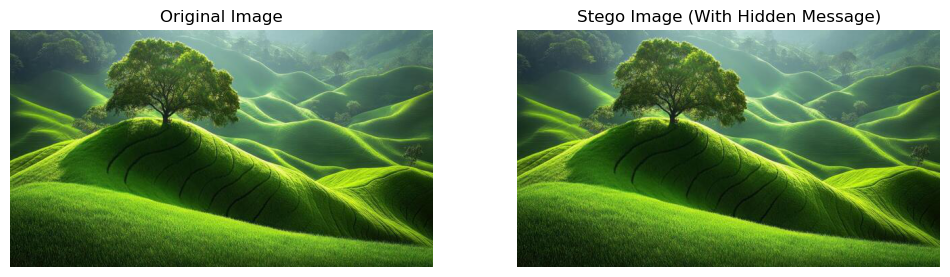

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

# Load both images
original = Image.open("input_image.jpg")
stego = Image.open("encoded_image.png")

# Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(stego)
axes[1].set_title("Stego Image (With Hidden Message)")
axes[1].axis('off')

plt.show()